# Analysis of BPE Fitting Result

In [1]:
import os
from pathlib import Path

os.chdir(Path.cwd().parents[0])
print("Now in:", Path.cwd())

dataPathCSV = str(Path.cwd()) + r"\data\csv" + "\\"
picklePath = str(Path.cwd()) + r"\out\pickle_objects\bpe" + "\\"
plotPath = str(Path.cwd()) + r"\out\plots\\bpe" + "\\"

Now in: C:\Users\stsax\OneDrive\Studium\9. Semester\Masterarbeit\Repository


In [2]:
import pickle

with open(picklePath + 'Fitted_BPE_State_Dict.pickle', 'rb') as f:
    state_dict = pickle.load(f)

In [3]:
from typing import Tuple
import pandas as pd

data_bpe = pd.read_parquet(dataPathCSV + r"Processed Files\data_bpe_train.parquet")

data_bpe_sample = data_bpe.sample(n = 10_000, random_state = 0, replace=False)

def extract_record(row) -> Tuple:
    time = row['Time Delta']
    channel = row['Channel']
    hex_data = row['Hex Data']

    return (time, channel, hex_data)

records_bpe = list(data_bpe_sample.apply(extract_record, axis=1))

In [4]:
import numpy as np
from bpe.bpe import BleBytePairEncoder, BPEConfig

config_bpe = BPEConfig()
unfitted_BPE = BleBytePairEncoder(config_bpe)
lengths_plain = np.array([len(x[5:]) for x in unfitted_BPE.encode_many(records_bpe)])

BPE = BleBytePairEncoder.from_state_dict(state_dict)
lengths_encoded = np.array([len(x[5:]) for x in BPE.encode_many(records_bpe)])

In [5]:
print("Avg. Length before BPE: ", np.mean(lengths_plain))
print("Avg. Length after BPE: ", np.mean(lengths_encoded))

print("Std. of Length before BPE: ", np.std(lengths_plain))
print("Std. of Length after BPE: ", np.std(lengths_encoded))

Avg. Length before BPE:  35.7875
Avg. Length after BPE:  22.8343
Std. of Length before BPE:  10.274830594710552
Std. of Length after BPE:  11.000647413220733


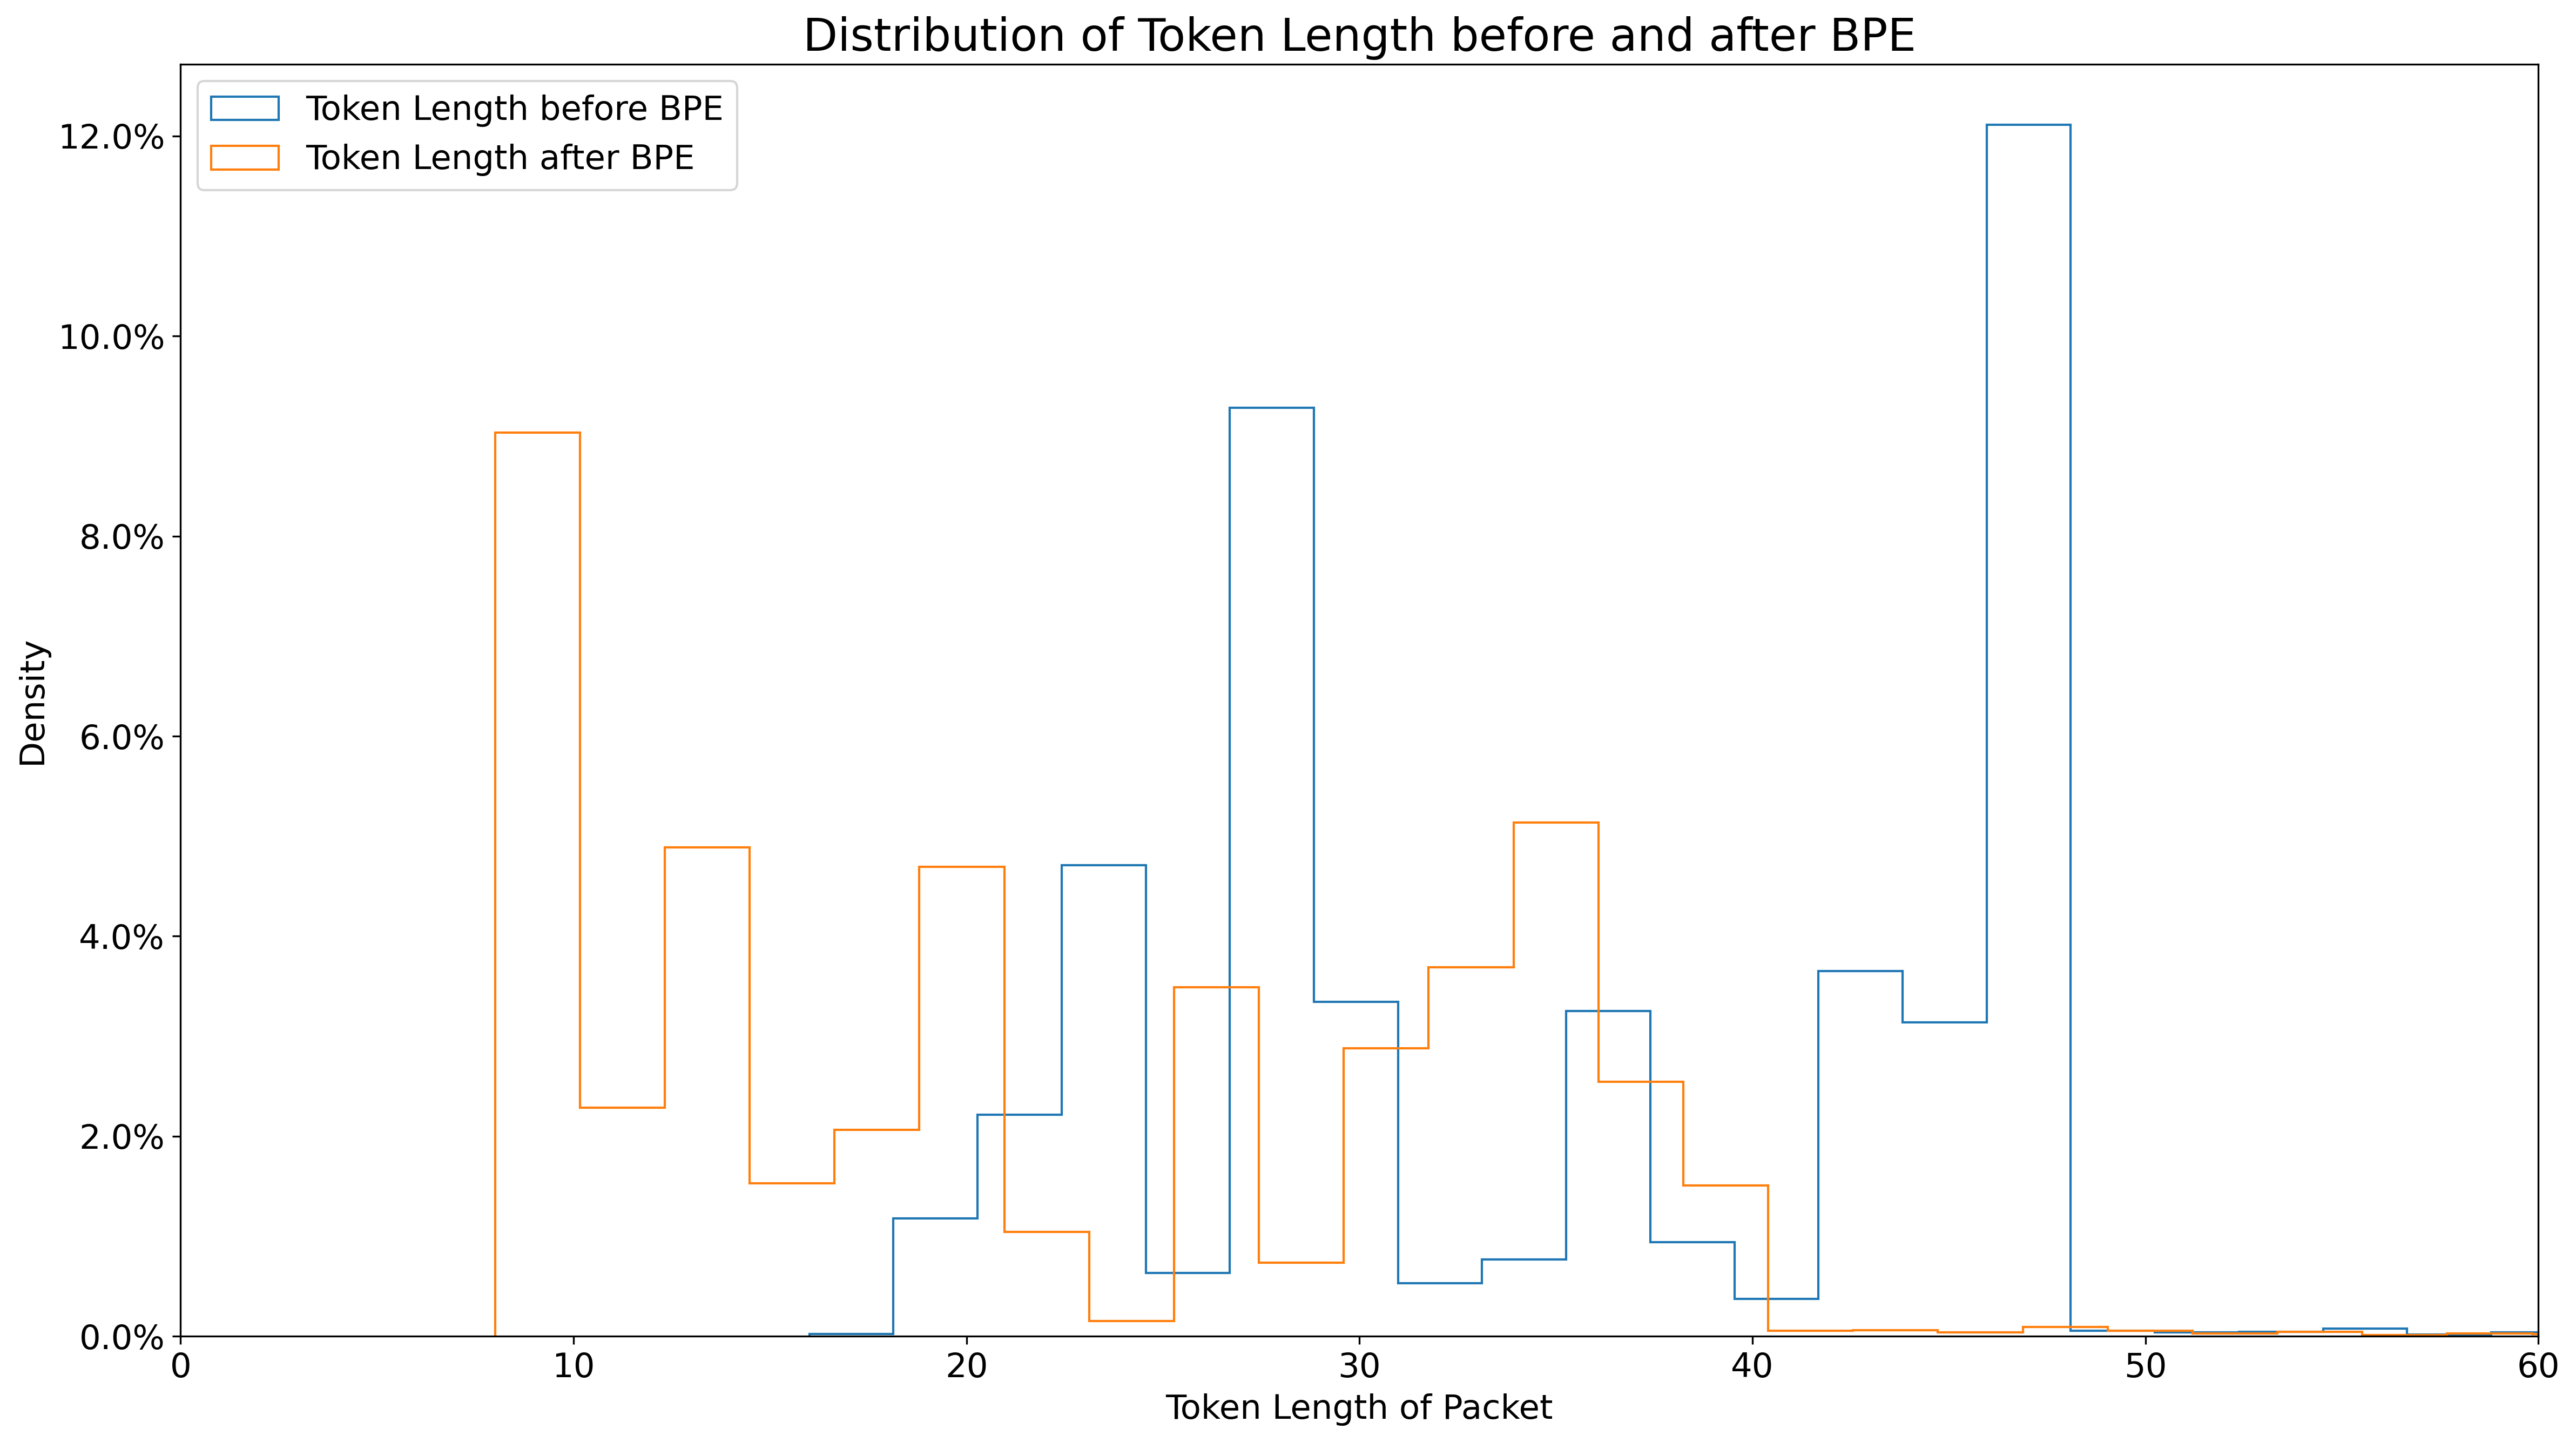

In [6]:
import matplotlib.pyplot as plt
from plotting.src.functions import FONTSIZE_TITLE, FONTSIZE_TICKS, FONTSIZE_LABEL
from matplotlib.ticker import PercentFormatter

plt.style.use('default')
plt.figure(figsize=(16,9), dpi = 300)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.hist(lengths_plain, bins = 50, density = True, histtype='step', color = 'C0', label = "Token Length before BPE")
plt.hist(lengths_encoded, bins = 50, density = True, histtype='step',color = 'C1', label = "Token Length after BPE")
plt.xlim(left = 0, right = 60)
plt.ylim(bottom = 0)
title = "Distribution of Token Length before and after BPE"
plt.title(title, fontsize = FONTSIZE_TITLE)
plt.xticks(fontsize = FONTSIZE_TICKS)
plt.yticks(fontsize = FONTSIZE_TICKS)
plt.xlabel("Token Length of Packet", fontsize = FONTSIZE_LABEL)
plt.ylabel("Density", fontsize = FONTSIZE_LABEL)
plt.legend(fontsize = FONTSIZE_LABEL)
plt.tight_layout()
plt.savefig(plotPath + title +".png", dpi = 300)
plt.show()